# ch305 — Loss Functions

## 1. What a loss function is

A loss function $\ell(\hat{y}, y)$ measures the cost of predicting $\hat{y}$ when the true
label is $y$. The training loss is its average over the dataset:

$$
\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N \ell(f_\theta(x^{(i)}), y^{(i)})
$$

Loss function design is not arbitrary. A good loss must:
1. Be **differentiable** almost everywhere (gradient descent requires $\nabla_\theta \mathcal{L}$).
2. Have a **minimum at the correct prediction** (otherwise the gradient points in the wrong direction).
3. Produce **informative gradients** even for nearly-correct predictions.
4. Be **statistically principled** — ideally derived from maximum likelihood estimation.

---

## 2. Mean Squared Error (regression)

$$
\ell_{\text{MSE}}(\hat{y}, y) = (\hat{y} - y)^2
$$

Gradient: $\partial \ell / \partial \hat{y} = 2(\hat{y} - y)$. Linear in the residual —
large errors produce large gradients, small errors produce small gradients.

**Statistical derivation:** MSE is the negative log-likelihood under a Gaussian noise model:
$y \sim \mathcal{N}(f_\theta(x), \sigma^2)$. Minimising MSE = maximising likelihood.

*(Gaussian distribution: ch253. Log-likelihood: ch293.)*

---

## 3. Binary Cross-Entropy (binary classification)

$$
\ell_{\text{BCE}}(\hat{p}, y) = -[y \log \hat{p} + (1-y) \log(1-\hat{p})]
$$

where $\hat{p} = \sigma(z) \in (0,1)$ is the predicted probability and $y \in \{0,1\}$.

**Why not MSE for classification?** If the output is a probability from a sigmoid,
MSE gradient $\frac{\partial \mathcal{L}}{\partial z} = (\hat{p} - y) \cdot \hat{p}(1-\hat{p})$
nearly vanishes when $\hat{p}$ is confident but wrong (sigmoid saturated).
BCE gradient: $\frac{\partial \mathcal{L}}{\partial z} = \hat{p} - y$ — clean, non-vanishing.

*(Entropy and KL divergence: ch294–ch295. Sigmoid: ch064.)*

---

## 4. Categorical Cross-Entropy (multiclass)

$$
\ell_{\text{CE}}(\hat{\mathbf{p}}, y) = -\log \hat{p}_y = -\sum_{k=1}^K y_k \log \hat{p}_k
$$

where $\hat{\mathbf{p}} = \text{softmax}(\mathbf{z})$ and $y$ is one-hot encoded.

**Softmax:**
$$
\hat{p}_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$

Combined gradient of CE + softmax: $\frac{\partial \mathcal{L}}{\partial \mathbf{z}} = \hat{\mathbf{p}} - \mathbf{y}$.
This elegant result is why CE+softmax is the universal choice for classification.

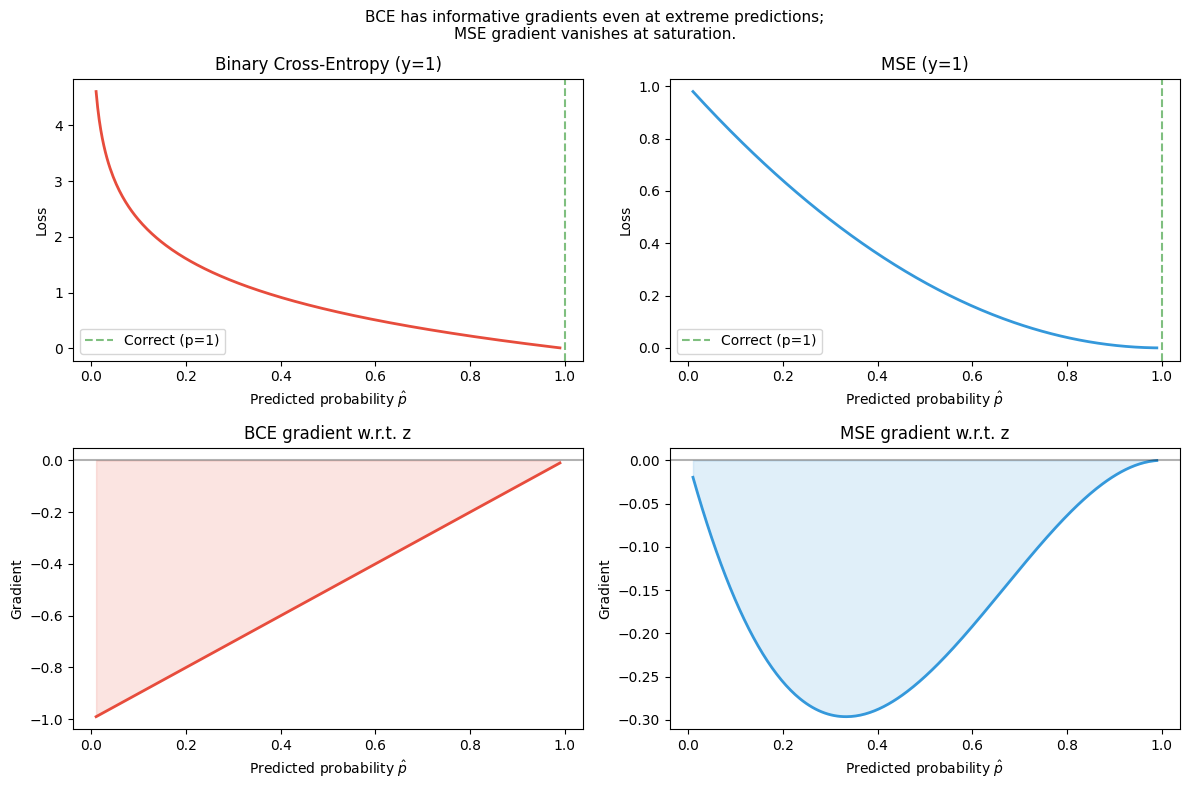

Confident wrong prediction (p=0.99, y=0):
  BCE gradient |dL/dz| = 0.9900  ← still strong
  MSE gradient |dL/dz| = 0.0196  ← nearly zero!


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def mse(y_hat: np.ndarray, y: np.ndarray) -> float:
    return float(np.mean((y_hat - y) ** 2))


def bce(p_hat: np.ndarray, y: np.ndarray, eps: float = 1e-12) -> float:
    """Binary cross-entropy. Clips to avoid log(0)."""
    p = np.clip(p_hat, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def softmax(z: np.ndarray) -> np.ndarray:
    """Numerically stable softmax using log-sum-exp trick."""
    z_shifted = z - z.max(axis=0, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum(axis=0, keepdims=True)


def cross_entropy(logits: np.ndarray, y_onehot: np.ndarray, eps: float = 1e-12) -> float:
    """Categorical cross-entropy from logits."""
    p = softmax(logits)
    return float(-np.mean(np.sum(y_onehot * np.log(p + eps), axis=0)))


# --- Visualise BCE vs MSE gradient behaviour ---
p = np.linspace(0.01, 0.99, 300)

# True label y=1
bce_loss = -(1 * np.log(p) + 0 * np.log(1 - p))
mse_loss = (1 - p) ** 2

# Gradients w.r.t. z (pre-sigmoid), using chain rule
# d(sigmoid)/dz = p*(1-p)
dbce_dz = p - 1          # p - y (when y=1)
dmse_dz = 2 * (p - 1) * p * (1 - p)   # MSE grad × sigmoid derivative

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, loss, name, color in [
    (axes[0, 0], bce_loss, 'Binary Cross-Entropy (y=1)', '#e74c3c'),
    (axes[0, 1], mse_loss, 'MSE (y=1)', '#3498db'),
]:
    ax.plot(p, loss, color=color, lw=2)
    ax.set_xlabel('Predicted probability $\\hat{p}$')
    ax.set_ylabel('Loss')
    ax.set_title(name)
    ax.axvline(1.0, color='green', linestyle='--', alpha=0.5, label='Correct (p=1)')
    ax.legend()

for ax, grad, name, color in [
    (axes[1, 0], dbce_dz, 'BCE gradient w.r.t. z', '#e74c3c'),
    (axes[1, 1], dmse_dz, 'MSE gradient w.r.t. z', '#3498db'),
]:
    ax.plot(p, grad, color=color, lw=2)
    ax.axhline(0, color='black', alpha=0.3)
    ax.set_xlabel('Predicted probability $\\hat{p}$')
    ax.set_ylabel('Gradient')
    ax.set_title(name)
    ax.fill_between(p, grad, 0, alpha=0.15, color=color)

plt.suptitle('BCE has informative gradients even at extreme predictions;\n'
             'MSE gradient vanishes at saturation.', fontsize=11)
plt.tight_layout()
plt.savefig('ch305_loss_gradients.png', dpi=120)
plt.show()

# Demonstration: gradient magnitude at nearly-wrong confident prediction
p_wrong = 0.99  # predicted 0.99 but true label is 0
bce_grad = p_wrong - 0
mse_grad = 2 * (p_wrong - 0) * p_wrong * (1 - p_wrong)
print(f"Confident wrong prediction (p={p_wrong}, y=0):")
print(f"  BCE gradient |dL/dz| = {abs(bce_grad):.4f}  ← still strong")
print(f"  MSE gradient |dL/dz| = {abs(mse_grad):.4f}  ← nearly zero!")

In [2]:
# --- Softmax behaviour ---
logits = np.array([[2.0, 1.0, 0.1, -1.0],
                   [5.0, 1.0, 0.1, -1.0],
                   [50.0, 1.0, 0.1, -1.0]])

print("Softmax concentrates probability mass as the winning logit grows:")
for z in logits:
    p = softmax(z[:, None]).ravel()
    print(f"  logits={z} → p={np.round(p, 3)}")

# Numerically UNSTABLE version for comparison
def softmax_unstable(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

large_z = np.array([1000.0, 999.0, 998.0])
print(f"\nUnstable softmax on large logits: {softmax_unstable.__name__}")
try:
    result = softmax_unstable(large_z)
    print(f"  Result: {result}  (overflow produces NaN/inf if not handled)")
except Exception as e:
    print(f"  Exception: {e}")

stable_result = softmax(large_z[:, None]).ravel()
print(f"Stable softmax (log-sum-exp): {stable_result}")

Softmax concentrates probability mass as the winning logit grows:
  logits=[ 2.   1.   0.1 -1. ] → p=[0.638 0.235 0.095 0.032]
  logits=[ 5.   1.   0.1 -1. ] → p=[0.973 0.018 0.007 0.002]
  logits=[50.   1.   0.1 -1. ] → p=[1. 0. 0. 0.]

Unstable softmax on large logits: softmax_unstable
  Result: [nan nan nan]  (overflow produces NaN/inf if not handled)
Stable softmax (log-sum-exp): [0.66524096 0.24472847 0.09003057]


C:\Users\user\AppData\Local\Temp\ipykernel_25912\3083791601.py:13: RuntimeWarning: overflow encountered in exp
  exp_z = np.exp(z)
C:\Users\user\AppData\Local\Temp\ipykernel_25912\3083791601.py:14: RuntimeWarning: invalid value encountered in divide
  return exp_z / exp_z.sum()


## 5. Huber loss (robust regression)

MSE is sensitive to outliers because $(\hat{y} - y)^2$ grows quadratically.
Huber loss interpolates between MSE (for small errors) and MAE (for large errors):

$$
\ell_\delta(\hat{y}, y) = \begin{cases}
\frac{1}{2}(\hat{y}-y)^2 & \text{if } |\hat{y}-y| \leq \delta \\
\delta\left(|\hat{y}-y| - \frac{\delta}{2}\right) & \text{otherwise}
\end{cases}
$$

Differentiable everywhere; gradient bounded by $\delta$. Used in reinforcement learning
*(ch329)* where reward estimates have heavy-tailed noise.

---

## 6. Choosing the loss function

| Task | Output activation | Loss |
|------|-------------------|------|
| Regression | Linear | MSE |
| Robust regression | Linear | Huber |
| Binary classification | Sigmoid | BCE |
| Multiclass (mutually exclusive) | Softmax | Categorical CE |
| Multilabel classification | Sigmoid (per class) | BCE (per class) |
| Generative models | Varies | KL divergence, ELBO |

---

## 7. Summary

- Loss functions must be differentiable and have informative gradients.
- MSE = negative log-likelihood under Gaussian noise. BCE = negative log-likelihood for Bernoulli.
- The BCE+sigmoid and CE+softmax gradients simplify to $\hat{p} - y$ — elegant and non-vanishing.
- Loss choice encodes assumptions about the noise distribution of the labels.

---

## 8. Forward and backward references

**Used here:** entropy *(ch294)*, KL divergence *(ch295)*, Gaussian distribution *(ch253)*,
log-likelihood *(ch293)*, sigmoid *(ch064)*, derivatives *(ch205–ch206)*.

**This will reappear in ch306 — Backpropagation from Scratch**, where the loss gradient
$\partial \mathcal{L}/\partial \hat{y}$ is the starting point of the backward pass,
and in ch325 — VAE, where the ELBO loss combines reconstruction CE and KL divergence.